# Encoding Categorical Data

## Feature Transformation(part of feature engineering) - done in two ways : 
- Feature Scaling
- Encoding Categorical Data

## Types of categorical data : 
- Nominal : categories have no correlation or order. Ex - states, engineering branch, etc
- Ordinal : they do. Ex - grades of students, ratings/reviews, etc. 

These categiries are usually in the form of strings, while the algorithm expects numeric values, hence we convert the categorical data into numeirc type using encoding.

Two popular methods : 
- Ordinal Encoding - for ordinal data 
- One Hot Encoding - nominal data 

## Ordinal Encoding
Since the classes are ordered, high numeirc values are assigned to the higher order ones and lower to the lower ones.
Ex : Education coumn with classes - PG, UG, HS(High School).
Then PG -> 2;
    UG -> 1;
    HS -> 0

### Label Encoding
In case of classification problems, when the output labels are categorical, we use label encoding instead of ordinal encoding on the output classes.

In [1]:
import numpy as np
import pandas as pd

In [5]:
df = pd.read_csv('customer.csv')
df.sample(5)

,age,gender,review,education,purchased
13,57,Female,Average,School,No
22,18,Female,Poor,PG,Yes
26,53,Female,Poor,PG,No
45,61,Male,Poor,PG,Yes
37,94,Male,Average,PG,Yes


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        50 non-null     int64
 1   gender     50 non-null     str  
 2   review     50 non-null     str  
 3   education  50 non-null     str  
 4   purchased  50 non-null     str  
dtypes: int64(1), str(4)
memory usage: 2.1 KB


In [24]:
df.groupby(df['education']).count()

,age,gender,review,purchased
education,,,,
PG,18,18,18,18
School,16,16,16,16
UG,16,16,16,16


### First step before feature transformation : train-test split

In [28]:
from sklearn.model_selection import train_test_split
df.sample(3)

,age,gender,review,education,purchased
39,76,Male,Poor,PG,No
23,96,Female,Good,School,No
45,61,Male,Poor,PG,Yes


Ordinal encoding would be applied to review and education cols

In [38]:
X = df.iloc[ : , 2:4]
y = df.iloc[ : ,-1]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2)
print(X_train.head(), "\n")
print(y_train.head())

     review education
7      Poor    School
25     Good    School
12     Poor    School
34  Average    School
18     Good    School 

7     Yes
25     No
12     No
34     No
18     No
Name: purchased, dtype: str


In [39]:
from sklearn.preprocessing import OrdinalEncoder

In [40]:
print(df.groupby('review').count())
print(df.groupby('education').count())

         age  gender  education  purchased
review                                    
Average   14      14         14         14
Good      18      18         18         18
Poor      18      18         18         18
           age  gender  review  purchased
education                                
PG          18      18      18         18
School      16      16      16         16
UG          16      16      16         16


In [ ]:
# Create a categories list with the lists of how you want to order the categories in each column
categories = [
    ['Poor', 'Average', 'Good'], # Order of the review categories
    ['School','UG', 'PG'] # Order of categories of the education categories
]
oe = OrdinalEncoder(categories=categories) # Ordinal encoding onject with the categorical orders

# fitting the model onto the training dataset
oe.fit(X_train)

X_train_encoded = oe.transform(X_train) # converts into an array also
X_test_encoded = oe.transform(X_test)

print("Original X_train : \n", X_train.head())
print("\n Transformed : \n", X_train_encoded[:6])

Original X_train : 
      review education
7      Poor    School
25     Good    School
12     Poor    School
34  Average    School
18     Good    School

 Transformed : 
 [[0. 0.]
 [2. 0.]
 [0. 0.]
 [1. 0.]
 [2. 0.]
 [0. 2.]]


you can see that poor and school are replaced by 0 and 0, Good and school by 2,0 and the encoding has been performed

### Label encoding the output cols

In [45]:
from sklearn.preprocessing import LabelEncoder

In [47]:
le = LabelEncoder() # decides on the assignment of 0 or 1 on its own
le.fit(y_train)

y_train_transform = le.transform(y_train)
y_test_tranform = le.transform(y_test)

print("Original y_train : \n", y_train.head())
print("\n Tranformed y_train : \n", y_train_transform[:6])

Original y_train : 
 7     Yes
25     No
12     No
34     No
18     No
Name: purchased, dtype: str

 Tranformed y_train : 
 [1 0 0 0 0 0]


## One Hot Encoding

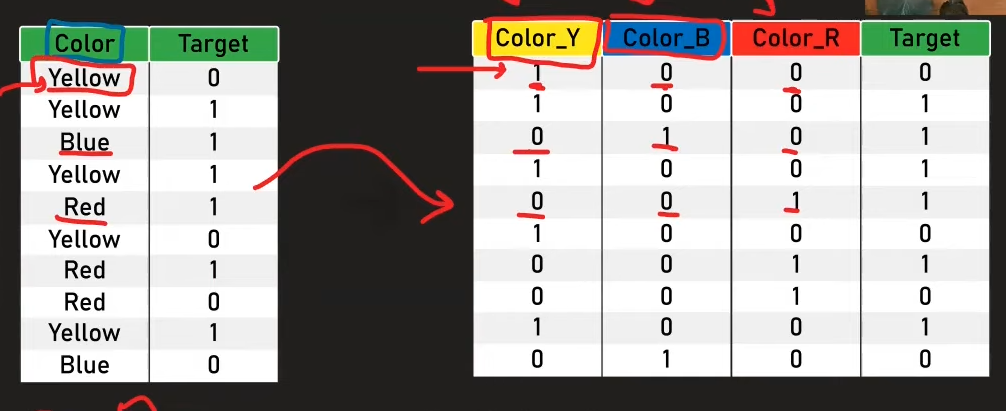

You simply represent each class using a vector where each dimension of that vector represents one of the classes(in no particular heirarchial order). Like here : 
- (y,b,r) is the how the vector is represented and
- 100 is for yellow
- 010 for blue
- 001 for red 

But this leads to the problem of multicollinearity as a mathematical relationship can form between the columns. Like here, sum of the vectors dimension values would always be 1. This poses problems in algorithms especially linear algorithms like linear and logistic regression. (This is known as the dummy variable trap.)

To prevent this, we remove one column(usually the first) and use n-1 cols for the encoding.

=> the final codes become : v(b,r) [vector representation] : y(00); b(10); r(01)

### OHE with frequently used categories
In cases of large number of categories for a column, in which only a few are occuring significantly, while the frequency of the rest is negligible compared to the ones with higher frequency, we group those other categories into a single category of 'others' and hence reduce the dimensionality of the vector. 

In [48]:
import numpy as np
import pandas as pd

In [49]:
df = pd.read_csv('../pandas/pokemon.csv')
df.head()

,No,Name,Type1,Type2,Height,Weight,Legendary
0,1,Bulbasaur,Grass,Poison,0.7,6.9,0
1,1,Bulbasaur,Grass,Poison,0.7,6.9,0
2,1,Bulbasaur,Grass,Poison,0.7,6.9,0
3,1,Bulbasaur,Grass,Poison,0.7,6.9,0
4,2,Ivysaur,Grass,Poison,1.0,13.0,0


In [50]:
df.groupby('Type1').count()

,No,Name,Type2,Height,Weight,Legendary
Type1,,,,,,
Bug,12,12,9,12,12,12
Dragon,3,3,1,3,3,3
Electric,9,9,3,9,9,9
Fairy,2,2,0,2,2,2
Fighting,7,7,0,7,7,7
Fire,12,12,2,12,12,12
Ghost,3,3,3,3,3,3
Grass,15,15,14,15,15,15
Ground,8,8,2,8,8,8


In [54]:
df['Type1'].value_counts() # To look at just the freq. of elements in the classes of that col SORTED

Type1
Water       28
Normal      22
Grass       15
Poison      14
Fire        12
Bug         12
Psychic     10
Electric     9
Rock         9
Ground       8
Fighting     7
Ghost        3
Dragon       3
Fairy        2
Ice          2
Name: count, dtype: int64

## OHE using Pandas

In [55]:
pd.get_dummies(df, columns=['Type1']) #parameters : (dataframe, columns=[list of columns to apply OHE to]) we're applying that to just one col here

,No,Name,Type2,Height,Weight,Legendary,Type1_Bug,Type1_Dragon,Type1_Electric,Type1_Fairy,...,Type1_Fire,Type1_Ghost,Type1_Grass,Type1_Ground,Type1_Ice,Type1_Normal,Type1_Poison,Type1_Psychic,Type1_Rock,Type1_Water
0,1,Bulbasaur,Poison,0.7,6.9,0,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1,1,Bulbasaur,Poison,0.7,6.9,0,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,1,Bulbasaur,Poison,0.7,6.9,0,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,1,Bulbasaur,Poison,0.7,6.9,0,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
4,2,Ivysaur,Poison,1.0,13.0,0,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,149,Dragonite,Flying,2.2,210.0,0,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
152,150,Mewtwo,NaN,2.0,122.0,1,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
153,150,Mewtwo,NaN,2.0,122.0,1,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
154,150,Mewtwo,NaN,2.0,122.0,1,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


Note that the dimensionality increased as a new col/variable for each category has been created. Also, cols for each category has been created, and hence the problem of multicollinearity persists.

### k-1 (or n-1) OHE 

In [56]:
pd.get_dummies(df, columns=['Type1'], drop_first=True) # drops the first category for each original col 

,No,Name,Type2,Height,Weight,Legendary,Type1_Dragon,Type1_Electric,Type1_Fairy,Type1_Fighting,Type1_Fire,Type1_Ghost,Type1_Grass,Type1_Ground,Type1_Ice,Type1_Normal,Type1_Poison,Type1_Psychic,Type1_Rock,Type1_Water
0,1,Bulbasaur,Poison,0.7,6.9,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,1,Bulbasaur,Poison,0.7,6.9,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False
2,1,Bulbasaur,Poison,0.7,6.9,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False
3,1,Bulbasaur,Poison,0.7,6.9,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False
4,2,Ivysaur,Poison,1.0,13.0,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,149,Dragonite,Flying,2.2,210.0,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False
152,150,Mewtwo,NaN,2.0,122.0,1,False,False,False,False,False,False,False,False,False,False,False,True,False,False
153,150,Mewtwo,NaN,2.0,122.0,1,False,False,False,False,False,False,False,False,False,False,False,True,False,False
154,150,Mewtwo,NaN,2.0,122.0,1,False,False,False,False,False,False,False,False,False,False,False,True,False,False


Notice the bug type removed

But pandas does not remember the order in which it places these now. So the order can change and another col may be dropped the second time. Hance, Pandas is not a reliable source to apply OHE for machine learning. hence we use the sklearn OHE

## OHE using sklearn

### Train-test split

In [57]:
from sklearn.model_selection import train_test_split

In [58]:
df.head()

,No,Name,Type1,Type2,Height,Weight,Legendary
0,1,Bulbasaur,Grass,Poison,0.7,6.9,0
1,1,Bulbasaur,Grass,Poison,0.7,6.9,0
2,1,Bulbasaur,Grass,Poison,0.7,6.9,0
3,1,Bulbasaur,Grass,Poison,0.7,6.9,0
4,2,Ivysaur,Grass,Poison,1.0,13.0,0


In [59]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=True)

In [60]:
X_train.head()

,No,Name,Type1,Type2,Height,Weight
66,64,Kadabra,Psychic,NaN,1.3,56.5
33,31,Nidoqueen,Poison,Ground,1.3,60.0
141,139,Omastar,Rock,Water,1.0,35.0
59,57,Primeape,Fighting,NaN,1.0,32.0
127,125,Electabuzz,Electric,NaN,1.1,30.0


In [61]:
from sklearn.preprocessing import OneHotEncoder

In [87]:
ohe = OneHotEncoder(drop='first', sparse_output=False, dtype='int32') #k-1 OHE ke liye drop first variable

Now to apply OHE using this method, we will first extract the col(s), to apply OHE to and then merge them back with the dataframe.

fitting and transforming the col 

In [88]:
X_train_new = ohe.fit_transform(X_train[['Type1']]) #DF[[list of cols to transform]] NOTICE THE TWO BRACKETS [[]]
print(X_train_new)
print(X_train_new.shape)


[[0 0 0 ... 1 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 1 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 1 0]
 [0 0 1 ... 0 0 0]]
(124, 14)


In [89]:
X_test_new = ohe.fit_transform(X_test[['Type1']])

We have performed OHE on the col. Now we need to merge the two.

In [ ]:
#Since the transformed cols are arrays, the dataframe also needs to be used as an array to merge the two: 
np.hstack((X_train.values, X_train_new)) # Since we need to append the col after No and Name cols

array([[64, 'Kadabra', 'Psychic', ..., 1, 0, 0],
       [31, 'Nidoqueen', 'Poison', ..., 0, 0, 0],
       [139, 'Omastar', 'Rock', ..., 0, 1, 0],
       ...,
       [70, 'Weepinbell', 'Grass', ..., 0, 0, 0],
       [138, 'Omanyte', 'Rock', ..., 0, 1, 0],
       [35, 'Clefairy', 'Fairy', ..., 0, 0, 0]],
      shape=(124, 20), dtype=object)

In [91]:
df.head()

,No,Name,Type1,Type2,Height,Weight,Legendary
0,1,Bulbasaur,Grass,Poison,0.7,6.9,0
1,1,Bulbasaur,Grass,Poison,0.7,6.9,0
2,1,Bulbasaur,Grass,Poison,0.7,6.9,0
3,1,Bulbasaur,Grass,Poison,0.7,6.9,0
4,2,Ivysaur,Grass,Poison,1.0,13.0,0


## OHE with Top Categories

In [ ]:
threshold = 10